# Customer Churn Prediction & Retention Analysis

This project uses machine learning to predict whether a telecommunications customer is likely to churn based on demographic, account, and service information.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Understanding

Before building machine learning models, we first examine the size, columns, data types, and target variable of the dataset.

In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [5]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Cleaning

We inspect the dataset for incorrect data types, missing values, and duplicate records before building machine learning models.

In [7]:
df["TotalCharges"].dtype

dtype('O')

In [8]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [9]:
df[df["TotalCharges"].str.strip() == ""][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [10]:
df["TotalCharges"] = (
    df["TotalCharges"]
    .str.strip()
    .replace("", "0")
)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

**Cleaning note:** The 11 blank `TotalCharges` entries belong to customers with `tenure = 0`. We replace those blank totals with 0 before converting the column to numeric. This is a dataset-specific choice rather than a general missing-value rule.

In [11]:
print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())

TotalCharges dtype: float64
Missing TotalCharges: 0


In [12]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0


## 3. Exploratory Data Analysis

We explore customer churn patterns and examine how important customer characteristics are associated with churn.

In [13]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [15]:
import matplotlib.pyplot as plt

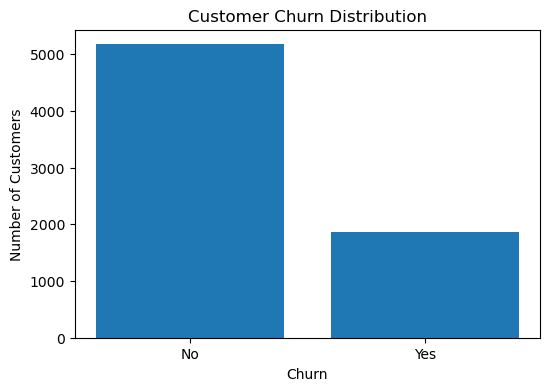

In [16]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [17]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [18]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [19]:
contract_churn_rate = contract_churn["Yes"]

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Yes, dtype: float64

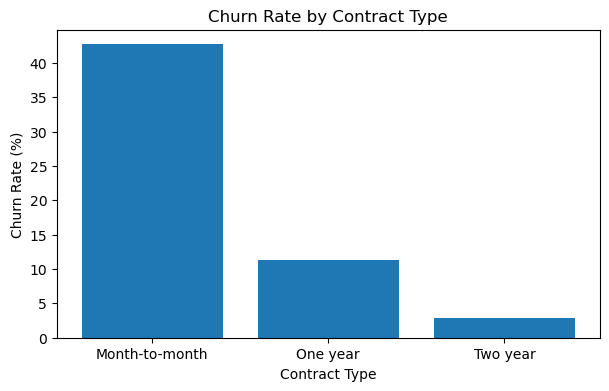

In [20]:
plt.figure(figsize=(7, 4))

plt.bar(
    contract_churn_rate.index,
    contract_churn_rate.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

**Insight:** Customers with month-to-month contracts have a much higher churn rate (42.7%) than customers with one-year (11.3%) or two-year contracts (2.8%). This suggests that contract type may be an important predictor of customer churn.

In [21]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [22]:
df.groupby("Churn")["tenure"].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

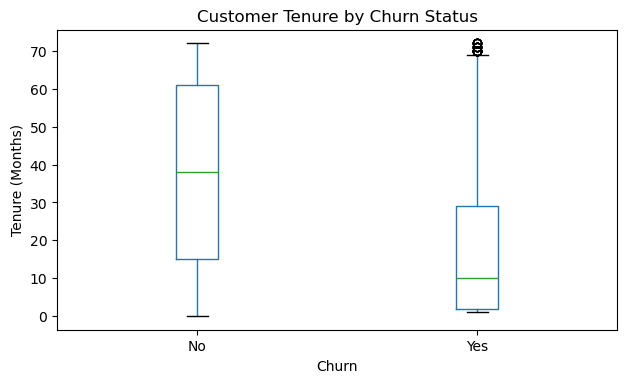

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))

df.boxplot(
    column="tenure",
    by="Churn",
    ax=ax,
    grid=False
)

ax.set_title("Customer Tenure by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Tenure (Months)")
fig.suptitle("")

plt.show()


**Insight:** Customers who churned generally had shorter tenure than those who stayed. The median tenure was approximately 10 months for churned customers, compared with 38 months for non-churned customers. This suggests that tenure may be an important predictor of customer churn.


In [24]:
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median"])

,mean,median
Churn,,
No,61.265124,64.425
Yes,74.441332,79.650


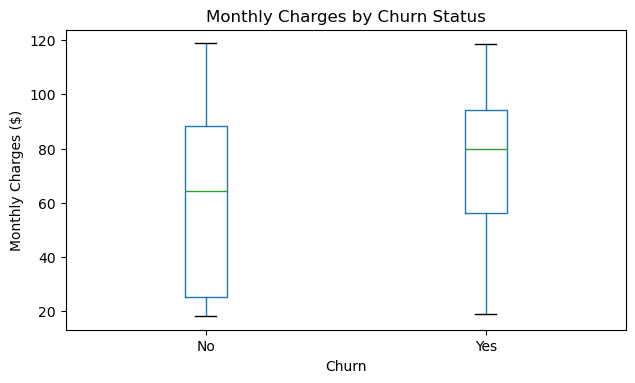

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))

df.boxplot(
    column="MonthlyCharges",
    by="Churn",
    ax=ax,
    grid=False
)

ax.set_title("Monthly Charges by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges ($)")
fig.suptitle("")

plt.show()



**Insight:** Customers who churned generally had higher monthly charges. Their average monthly charge was $74.44, compared with $61.27 for non-churned customers. This suggests that monthly charges may be an important predictor of customer churn.




### 3.1 Additional Exploratory Data Analysis

We examine churn rates across all categorical features to identify additional patterns and potential relationships with customer churn.



In [26]:
categorical_features = [
    col for col in df.select_dtypes(include=["object"]).columns
    if col not in ["customerID", "Churn"]
] + ["SeniorCitizen"]

eda_results = []

for feature in categorical_features:
    stats = df.groupby(feature)["Churn"].agg(
        customers="size",
        churn_rate=lambda x: (x == "Yes").mean() * 100
    )

    eda_results.append({
        "Feature": feature,
        "Categories": len(stats),
        "Min Churn Rate": round(stats["churn_rate"].min(), 2),
        "Max Churn Rate": round(stats["churn_rate"].max(), 2),
        "Difference": round(
            stats["churn_rate"].max() - stats["churn_rate"].min(), 2
        )
    })

eda_summary = pd.DataFrame(eda_results)

eda_summary = eda_summary.sort_values(
    by="Difference",
    ascending=False
)

eda_summary


,Feature,Categories,Min Churn Rate,Max Churn Rate,Difference
12,Contract,3,2.83,42.71,39.88
5,InternetService,3,7.40,41.89,34.49
6,OnlineSecurity,3,7.40,41.77,34.36
9,TechSupport,3,7.40,41.64,34.23
7,OnlineBackup,3,7.40,39.93,32.52
8,DeviceProtection,3,7.40,39.13,31.72
14,PaymentMethod,4,15.24,45.29,30.04
11,StreamingMovies,3,7.40,33.68,26.28
10,StreamingTV,3,7.40,33.52,26.12
15,SeniorCitizen,2,23.61,41.68,18.08


In [27]:
from IPython.display import display

features_to_explore = [
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod"
]

for feature in features_to_explore:
    summary = df.groupby(feature)["Churn"].agg(
        customers="size",
        churned=lambda x: (x == "Yes").sum(),
        churn_rate=lambda x: (x == "Yes").mean() * 100
    )

    summary["churn_rate"] = summary["churn_rate"].round(2)

    print(f"\n{feature}")
    display(summary.sort_values("churn_rate", ascending=False))



InternetService


,customers,churned,churn_rate
InternetService,,,
Fiber optic,3096,1297,41.89
DSL,2421,459,18.96
No,1526,113,7.40



OnlineSecurity


,customers,churned,churn_rate
OnlineSecurity,,,
No,3498,1461,41.77
Yes,2019,295,14.61
No internet service,1526,113,7.40



TechSupport


,customers,churned,churn_rate
TechSupport,,,
No,3473,1446,41.64
Yes,2044,310,15.17
No internet service,1526,113,7.40



PaymentMethod


,customers,churned,churn_rate
PaymentMethod,,,
Electronic check,2365,1071,45.29
Mailed check,1612,308,19.11
Bank transfer (automatic),1544,258,16.71
Credit card (automatic),1522,232,15.24


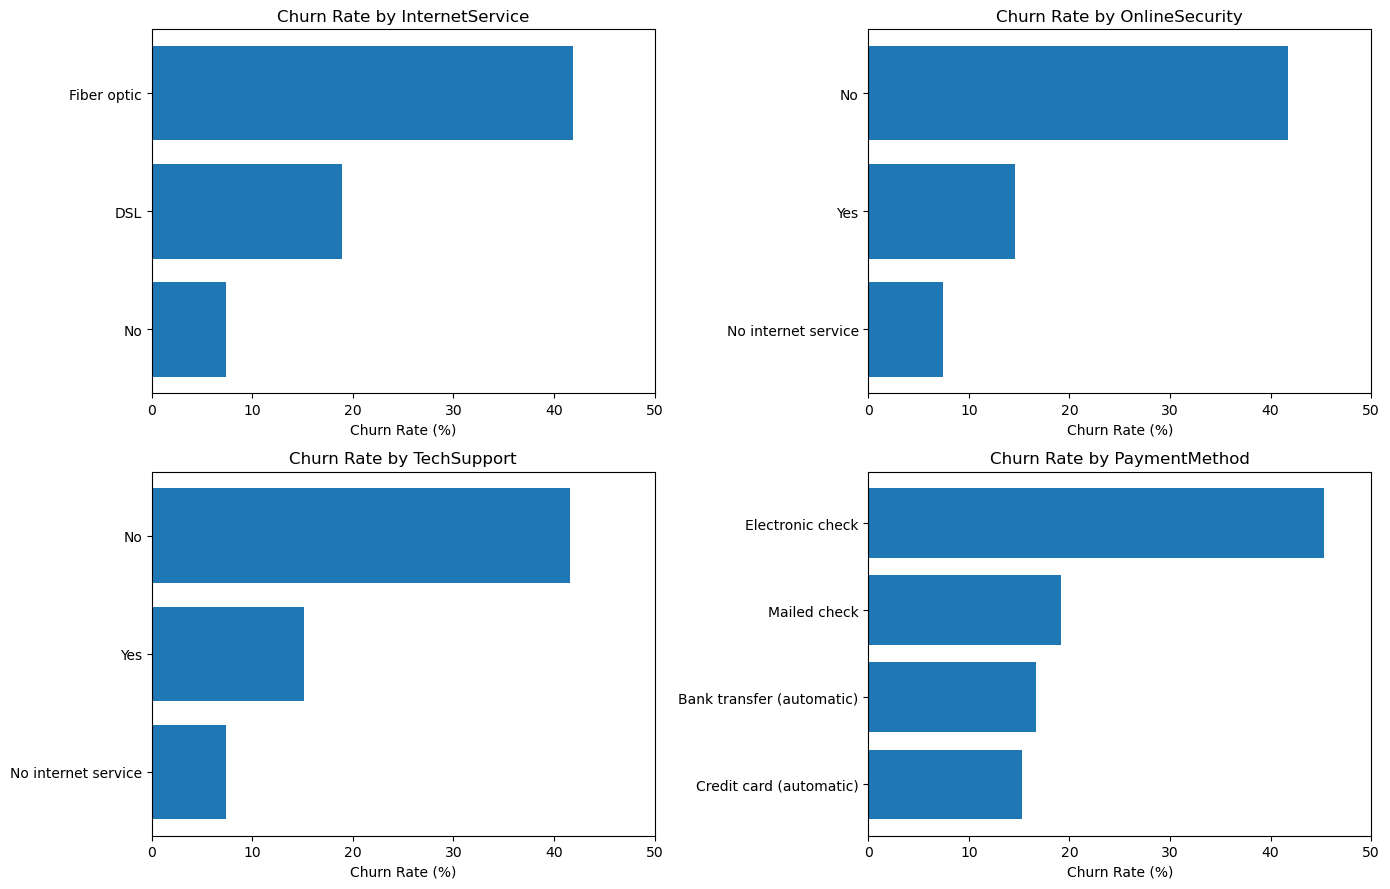

In [28]:
features_to_plot = [
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, feature in zip(axes.flatten(), features_to_plot):

    churn_rates = (
        df.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values()
    )

    ax.barh(churn_rates.index, churn_rates.values)

    ax.set_title(f"Churn Rate by {feature}")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_xlim(0, 50)

plt.tight_layout()
plt.show()



**Insight:** Customers using fiber optic internet, electronic checks, or lacking online security and technical support showed relatively high churn rates. These findings suggest that service characteristics and payment methods may be useful predictors of customer churn, although the relationships do not establish causation.


In [29]:
correlation = df["tenure"].corr(df["TotalCharges"])

print("Correlation between tenure and TotalCharges:",
      round(correlation, 3))


Correlation between tenure and TotalCharges: 0.826


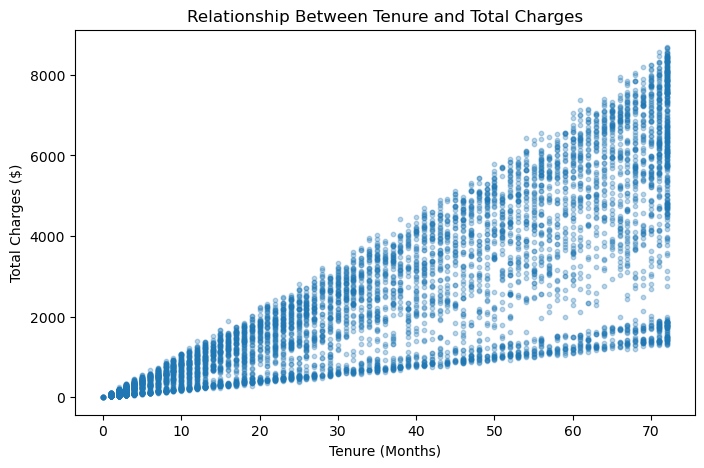

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["tenure"],
    df["TotalCharges"],
    alpha=0.3,
    s=10
)

plt.title("Relationship Between Tenure and Total Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges ($)")

plt.show()



**Insight:** Tenure and TotalCharges show a strong positive correlation (r = 0.826). Customers with longer tenure generally have higher cumulative charges. However, the variation in monthly charges creates a wide distribution of TotalCharges, especially among long-term customers. This relationship suggests potential multicollinearity between these features.


In [31]:
df.groupby("Churn")["TotalCharges"].agg(["mean", "median"])

,mean,median
Churn,,
No,2549.911442,1679.525
Yes,1531.796094,703.550



**Insight:** Customers who churned had lower total charges on average ($1,531.80) than customers who stayed ($2,549.91). Although churned customers generally had higher monthly charges, their shorter tenure may explain their lower cumulative payments. This highlights the importance of examining relationships among multiple features.



## 4. Data Preprocessing

We separate the dataset into features (X) and the target variable (y) before training machine learning models.


In [32]:
X = df.drop(columns=["Churn", "customerID"])

y = df["Churn"].map({"No": 0, "Yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (7043, 19)
y shape: (7043,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [34]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)

print("\nNumber of categorical features:", len(categorical_cols))
print("Number of numerical features:", len(numerical_cols))


Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Number of categorical features: 15
Number of numerical features: 4


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (5634, 45)
Processed testing shape: (1409, 45)


## 5. Machine Learning Models

### 5.1 Logistic Regression

We train a Logistic Regression model to predict customer churn using the preprocessed training data.

In [36]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_processed, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [37]:
y_pred = lr_model.predict(X_test_processed)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test.iloc[:10].values)


First 10 predictions: [0 1 0 0 0 1 0 0 0 0]
First 10 actual values: [0 0 0 0 0 0 0 0 0 1]


In [38]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")


Logistic Regression Accuracy: 80.55 %


### 5.2 Logistic Regression Evaluation

We evaluate the model using precision, recall, F1-score, and a confusion matrix to understand its performance beyond accuracy.

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



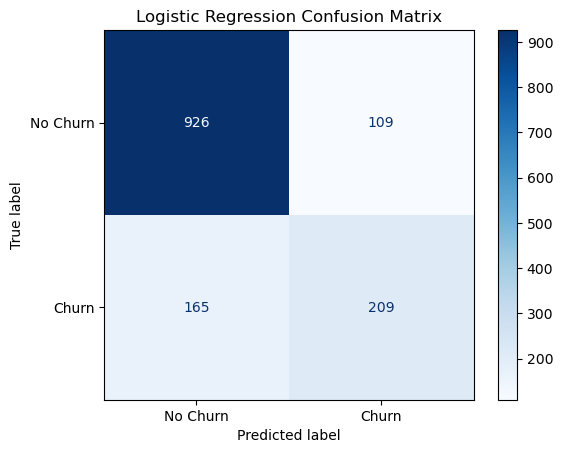

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()


**Insight:** The Logistic Regression model achieved 80.55% accuracy, with 65.72% precision, 55.88% recall, and 60.40% F1-score for churn prediction. However, it failed to identify 165 out of 374 actual churned customers, suggesting that improving recall could help identify more at-risk customers.

### 5.3 Decision Tree

We train a Decision Tree classifier and use cross-validation to evaluate its ability to predict customer churn.

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=5, random_state=42))
])

cv_scores = cross_val_score(
    tree_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

tree_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [42]:
train_pred = tree_pipeline.predict(X_train)

print("Training F1:", round(f1_score(y_train, train_pred), 3))
print("Cross-validation F1 scores:", cv_scores.round(3))
print("Mean CV F1:", round(cv_scores.mean(), 3))


Training F1: 0.602
Cross-validation F1 scores: [0.629 0.526 0.543 0.597 0.507]
Mean CV F1: 0.56


**Insight:** The Decision Tree achieved a training F1-score of 0.602 and a mean 5-fold cross-validation F1-score of 0.560. The relatively small gap suggests limited overfitting, although performance varies across validation folds.

### 5.4 Random Forest

We train a Random Forest classifier and evaluate its performance using 5-fold cross-validation.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1
    ))
])

rf_cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

rf_pipeline.fit(X_train, y_train)

rf_train_pred = rf_pipeline.predict(X_train)

print("Training F1:", round(f1_score(y_train, rf_train_pred), 3))
print("Cross-validation F1 scores:", rf_cv_scores.round(3))
print("Mean CV F1:", round(rf_cv_scores.mean(), 3))


Training F1: 0.634
Cross-validation F1 scores: [0.617 0.563 0.598 0.55  0.553]
Mean CV F1: 0.576


**Insight:** The Random Forest achieved a training F1-score of 0.637 and a mean 5-fold cross-validation F1-score of 0.576, slightly outperforming the Decision Tree (0.560 CV F1). The gap between training and validation performance suggests some overfitting, but not necessarily severe overfitting.

### 5.5 Model Comparison

We compare Logistic Regression, Decision Tree, and Random Forest using the same 5-fold cross-validation approach and F1-score metric.

In [44]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_cv_scores = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Logistic Regression CV F1 scores:", lr_cv_scores.round(3))
print("Logistic Regression Mean CV F1:", round(lr_cv_scores.mean(), 3))


Logistic Regression CV F1 scores: [0.651 0.585 0.597 0.578 0.58 ]
Logistic Regression Mean CV F1: 0.598


In [45]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Mean CV F1": [
        lr_cv_scores.mean(),
        cv_scores.mean(),
        rf_cv_scores.mean()
    ]
})

results_df = results_df.sort_values(
    by="Mean CV F1",
    ascending=False
)

results_df


,Model,Mean CV F1
0,Logistic Regression,0.597988
2,Random Forest,0.576122
1,Decision Tree,0.560241


**Insight:** Logistic Regression achieved the highest mean cross-validation F1-score (0.598), followed by Random Forest (0.576) and Decision Tree (0.560). This suggests that a simpler model may perform better on this dataset under the current settings.

## 6. Hyperparameter Tuning

We use GridSearchCV to optimize Logistic Regression hyperparameters based on cross-validation F1-score.

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 3))


Best Parameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
Best CV F1: 0.633


**Insight:** Hyperparameter tuning improved the Logistic Regression cross-validation F1-score from 0.598 to 0.633. The best parameters were C=0.1 and class_weight="balanced", suggesting that stronger regularization and class weighting improved performance under the current validation setup.

## 7. Final Model Evaluation

We evaluate the tuned Logistic Regression model on the held-out test set using accuracy, precision, recall, and F1-score.

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_model = grid_search.best_estimator_

final_pred = best_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, final_pred), 3))
print("Precision:", round(precision_score(y_test, final_pred), 3))
print("Recall:", round(recall_score(y_test, final_pred), 3))
print("F1-score:", round(f1_score(y_test, final_pred), 3))


Accuracy: 0.742
Precision: 0.509
Recall: 0.786
F1-score: 0.618


**Insight:** The tuned Logistic Regression model achieved 74.2% accuracy, 50.9% precision, 78.6% recall, and 61.8% F1-score. Compared with the original model, recall increased substantially while precision and accuracy decreased. This trade-off may be beneficial when identifying more at-risk customers is a business priority.

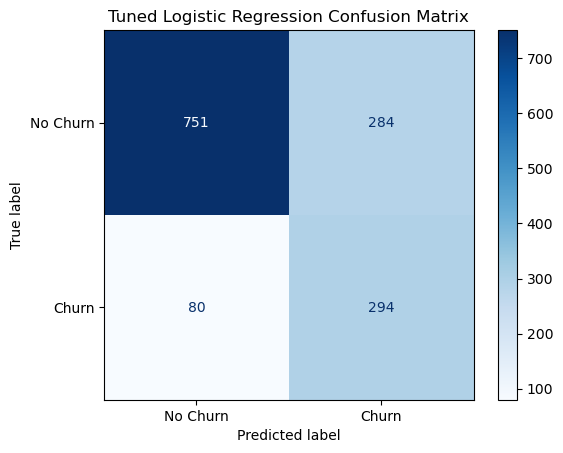

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Tuned Logistic Regression Confusion Matrix")
plt.show()


**Insight:** After hyperparameter tuning, the model reduced false negatives from 165 to 80, identifying 85 additional churned customers. However, false positives increased from 109 to 284. This demonstrates the trade-off between improving recall and increasing false positives.

## 8. Model Interpretation

We examine the Logistic Regression coefficients to understand which features are most strongly associated with predicted customer churn.

In [49]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = best_model.named_steps["classifier"].coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df["Absolute Coefficient"] = importance_df["Coefficient"].abs()

importance_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
).head(10)


,Feature,Coefficient,Absolute Coefficient
42,num__tenure,-0.985160,0.985160
32,cat__Contract_Month-to-month,0.681638,0.681638
34,cat__Contract_Two year,-0.645968,0.645968
12,cat__InternetService_Fiber optic,0.394112,0.394112
11,cat__InternetService_DSL,-0.316807,0.316807
44,num__TotalCharges,0.299479,0.299479
39,cat__PaymentMethod_Electronic check,0.284603,0.284603
14,cat__OnlineSecurity_No,0.254940,0.254940
23,cat__TechSupport_No,0.222235,0.222235
16,cat__OnlineSecurity_Yes,-0.177635,0.177635


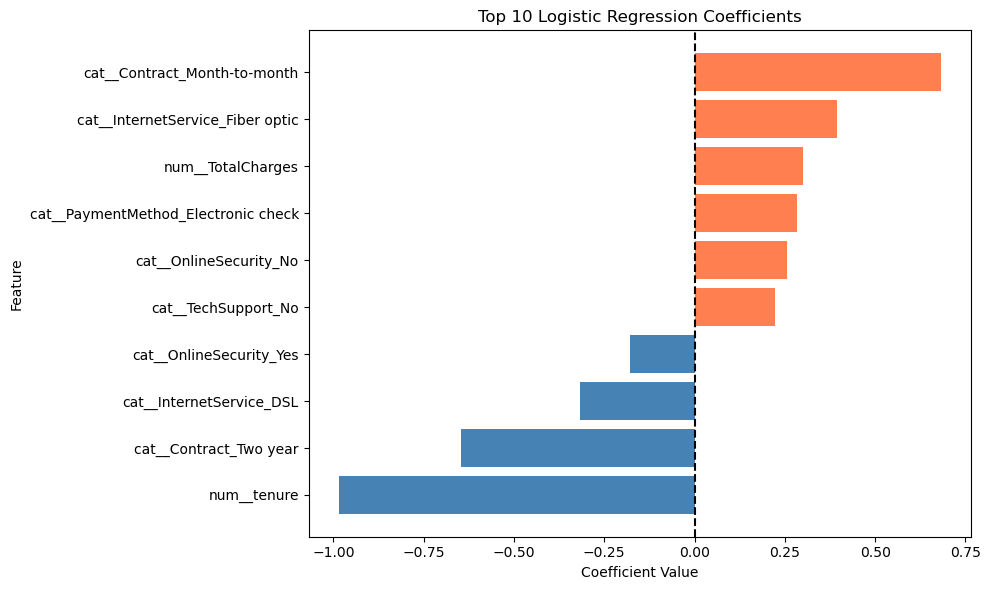

In [50]:
top_features = importance_df.nlargest(
    10, "Absolute Coefficient"
).sort_values("Coefficient")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"],
    color=["steelblue" if x < 0 else "coral"
           for x in top_features["Coefficient"]]
)

plt.axvline(x=0, color="black", linestyle="--")

plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()



**Insight:** Model coefficients suggest that tenure, contract type, and internet service type are strongly associated with predicted customer churn. Longer tenure and two-year contracts are associated with lower predicted churn, while month-to-month contracts are associated with higher predicted churn. These relationships do not necessarily imply causation.



## 9. Project Conclusions

### Key Findings

This project analyzed 7,043 telecommunications customers and developed machine learning models to predict customer churn.

1. **Contract Type:** Month-to-month customers had the highest churn rate (42.7%), compared with one-year (11.3%) and two-year contracts (2.8%).

2. **Customer Tenure:** Customers who churned generally had shorter tenure, suggesting that newer customers may be more vulnerable to churn.

3. **Monthly Charges:** Churned customers had higher average monthly charges ($74.44) than non-churned customers ($61.27).

4. **Services and Payment Methods:** Customers using fiber optic internet, electronic checks, or lacking online security and technical support showed relatively high churn rates.

### Model Performance

Three machine learning models were compared using 5-fold cross-validation: Logistic Regression, Decision Tree, and Random Forest.

Logistic Regression achieved the highest initial mean CV F1-score (0.598). After hyperparameter tuning, the selected model achieved:

- Accuracy: 74.2%
- Precision: 50.9%
- Recall: 78.6%
- F1-score: 61.8%

The tuned model identified 294 out of 374 actual churned customers in the test set, demonstrating improved recall compared with the original model.

### Business Implications

The findings suggest that companies could prioritize reviewing customers with month-to-month contracts, shorter tenure, and certain service characteristics when developing retention strategies.

However, the higher recall comes with more false positives, so businesses should consider the costs of unnecessary retention interventions.

### Limitations and Future Work

The results are based on an existing telecommunications dataset and do not establish causal relationships.

Future improvements could include additional validation, probability threshold optimization, more advanced feature interpretation, and evaluating the costs and benefits of customer retention strategies.
